# Human-Mouse Ortholog Analysis: Double Peaks & Poisson P-Values

Investigates:
1. The bimodal distributions in `prob_overlap` and `query_tfidf` for ortholog pairs
2. Whether specific k-mers or short proteins drive the second peak
3. Correct Poisson p-value calculation: P(X ≥ k | λ) = `poisson.sf(k-1, λ)`
4. BH correction and comparison with existing `prob_overlap`

**Data**: `/Users/olga/data/gencode/results-human-mouse-orthologs/`  
**K-size**: 24, HP encoding

### Background
The existing `prob_overlap` in the CSV is **not a p-value** — it is:
$$\text{prob\_overlap} = \sum_{h \in \text{intersection}} f_q(h) \cdot f_t(h)$$
where $f_q(h)$ and $f_t(h)$ are k-mer frequencies across the query proteome and target proteome.

The correct Poisson p-value is:
$$p = P(X \geq k \mid \lambda) = \text{Poisson.sf}(k-1, \lambda)$$
where $k = $ `n_intersecting_hashes` (observed) and $\lambda = $ `expected_shared_kmers` (expected by chance).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import poisson as _poisson
from sklearn.metrics import roc_curve, auc
import re

# ── paths ────────────────────────────────────────────────────────────────────
DATA_DIR   = "/Users/olga/data/gencode/results-human-mouse-orthologs"
KSIZE      = 24
ALPHA      = 0.05
HIGH_CONF  = 1e-5
SAMPLE_FRAC = 0.05   # sample ~5% of rows → ~940k rows from 18.8M total
RANDOM_SEED = 42

EVAL_TSV   = f"{DATA_DIR}/ortholog_evaluation.hp.k{KSIZE}.tsv"
ROC_TSV    = f"{DATA_DIR}/ortholog_evaluation.hp.k{KSIZE}.roc_data.tsv"
SUMMARY_TXT = f"{DATA_DIR}/ortholog_evaluation.hp.k{KSIZE}.summary.txt"

sns.set_theme(style='whitegrid', context='notebook')
print(f"Pandas {pd.__version__}, NumPy {np.__version__}")

Pandas 3.0.1, NumPy 2.3.5


## 1. Load Data (sampled)

In [2]:
# Chunked read with reservoir-like sampling
# File is ~11 GB with ~18.8M rows; we sample ~5% per chunk → ~940k rows
CHUNK = 500_000
rng = np.random.default_rng(RANDOM_SEED)

chunks = []
for chunk in pd.read_csv(EVAL_TSV, sep='\t', chunksize=CHUNK):
    mask = rng.random(len(chunk)) < SAMPLE_FRAC
    chunks.append(chunk[mask])

df = pd.concat(chunks, ignore_index=True)
print(f"Loaded {len(df):,} rows  (orthologs: {df['is_ortholog'].sum():,})")
df.head(2)

Loaded 939,282 rows  (orthologs: 34,325)


,query_name,query_md5,target_name,target_md5,containment,n_intersecting_hashes,ksize,scaled,moltype,jaccard,...,query_end,query_subseq,target_start,target_end,target_subseq,moltype_seq,region_length,human_gene,mouse_gene,is_ortholog
0,ENSP00000493376.2|ENST00000641515.2|ENSG000001...,f3c6aee77a599e8f,ENSMUSP00000138000.2|ENSMUST00000181904.3|ENSM...,ee0a378a123fabe4,0.0033,1,24,1,hp,0.001550,...,61,QTFLFMLFFVFYGGIVFGNLLIVI,136,160,SSAILPAAGGGGGGGGGGSGGGGG,pphhhhhhhhhhhhhhhhphhhhh,24,OR4F5,Cxxc4,False
1,ENSP00000493376.2|ENST00000641515.2|ENSG000001...,f3c6aee77a599e8f,ENSMUSP00000153359.2|ENSMUST00000224208.2|ENSM...,eb93f831a8a4247f,0.0033,1,24,1,hp,0.000716,...,263,QHRPLDKSSKALSTLTAHITVVLL,197,221,QQHIYDHSHCGVSDLTGSGKPWWL,ppphhppppphhpphphphphhhh,24,OR4F5,Adamts6,False


In [3]:
# Parse protein length from query_name (last pipe-separated field is aa length)
df['query_len'] = df['query_name'].str.split('|').str[-1].astype(int)
df['target_len'] = df['target_name'].str.split('|').str[-1].astype(int)
df['shorter_protein_len'] = df[['query_len', 'target_len']].min(axis=1)

print("Query length stats:")
print(df['query_len'].describe(percentiles=[.05,.25,.5,.75,.95]))
print(f"\nRows with protein len < 50: {(df['query_len'] < 50).sum():,}")
print(f"Rows with protein len < 100: {(df['query_len'] < 100).sum():,}")

Query length stats:
count    939282.000000
mean       1096.541291
std        1469.367313
min          25.000000
5%          254.000000
25%         476.000000
50%         808.000000
75%        1301.000000
95%        2752.000000
max       35991.000000
Name: query_len, dtype: float64

Rows with protein len < 50: 57
Rows with protein len < 100: 1,775


## 2. The Double Peaks: Distribution Plots

Let's see the raw distributions of `prob_overlap` and `query_tfidf` by ortholog status.

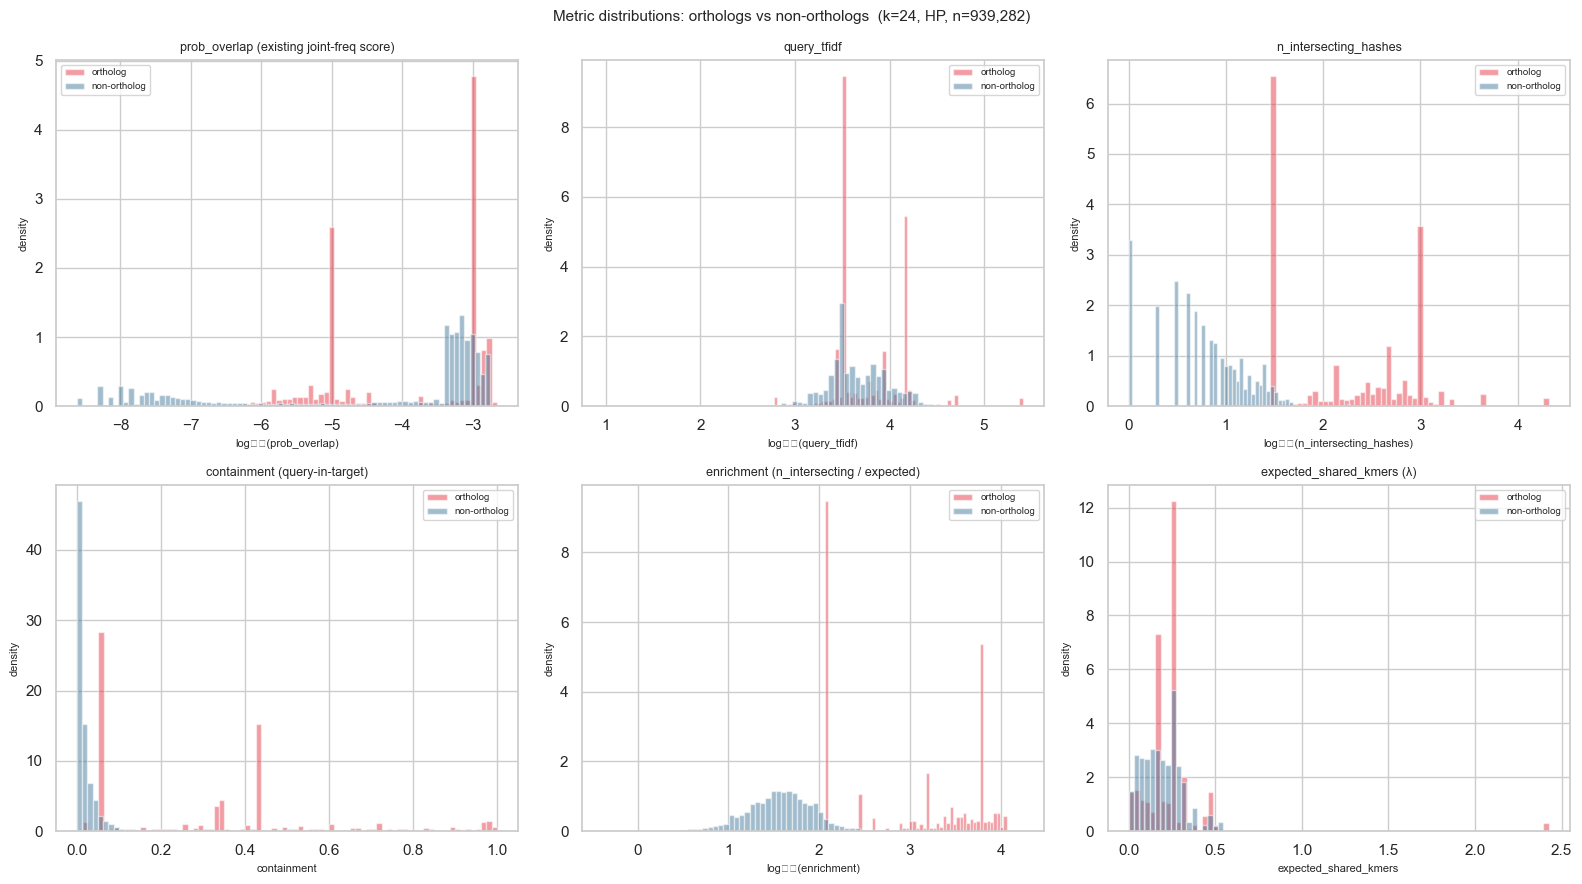

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

metrics = [
    ('prob_overlap',          'prob_overlap (existing joint-freq score)',      'log'),
    ('query_tfidf',           'query_tfidf',                                   'log'),
    ('n_intersecting_hashes', 'n_intersecting_hashes',                         'log'),
    ('containment',           'containment (query-in-target)',                  'linear'),
    ('enrichment',            'enrichment (n_intersecting / expected)',          'log'),
    ('expected_shared_kmers', 'expected_shared_kmers (λ)',                      'linear'),
]

pal = {True: '#e63946', False: '#457b9d'}  # red=ortholog, blue=non-ortholog

for ax, (col, label, scale) in zip(axes.flat, metrics):
    vals = df[col].replace(0, np.nan).dropna()
    sub = df.loc[vals.index, ['is_ortholog', col]].copy()
    if scale == 'log':
        sub[col] = np.log10(sub[col].clip(lower=1e-20))
        xlabel = f'log₁₀({col})'
    else:
        xlabel = col

    for is_orth, color in pal.items():
        data = sub.loc[sub['is_ortholog'] == is_orth, col]
        label_str = 'ortholog' if is_orth else 'non-ortholog'
        data.hist(ax=ax, bins=80, alpha=0.5, color=color, label=label_str, density=True)

    ax.set_title(label, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel('density', fontsize=8)
    ax.legend(fontsize=7)

fig.suptitle(f'Metric distributions: orthologs vs non-orthologs  (k={KSIZE}, HP, n={len(df):,})',
             fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_distributions.hp.k{KSIZE}.png', dpi=150)
plt.show()

## 3. Investigating the Double Peaks

### 3a. Is protein length driving bimodality?

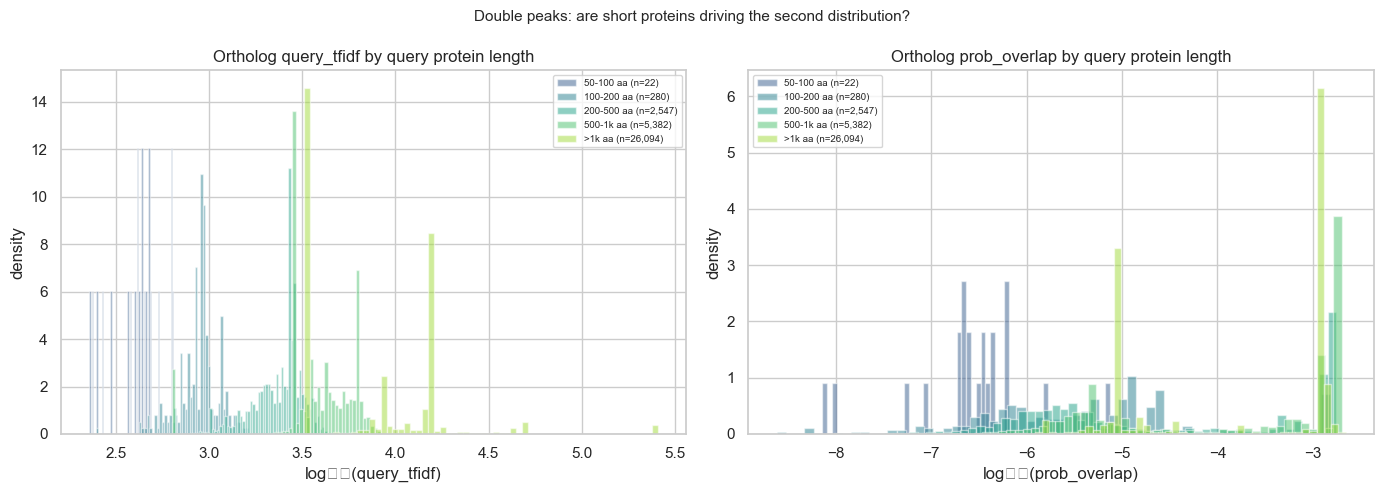

In [5]:
# Ortholog-only data, grouped by short/long protein
orth = df[df['is_ortholog']].copy()

# Define length bins
LEN_BINS   = [0, 50, 100, 200, 500, 1000, 99999]
LEN_LABELS = ['<50', '50-100', '100-200', '200-500', '500-1k', '>1k']
orth['len_bin'] = pd.cut(orth['query_len'], bins=LEN_BINS, labels=LEN_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, label) in zip(axes, [
    ('query_tfidf', 'log₁₀(query_tfidf)'),
    ('prob_overlap', 'log₁₀(prob_overlap)'),
]):
    plot_vals = np.log10(orth[col].clip(lower=1e-20))
    orth_plot = orth.assign(**{f'log_{col}': plot_vals})

    palette = sns.color_palette('viridis', n_colors=len(LEN_LABELS))
    for i, lb in enumerate(LEN_LABELS):
        sub = orth_plot.loc[orth_plot['len_bin'] == lb, f'log_{col}'].dropna()
        if len(sub) > 10:
            sub.hist(ax=ax, bins=60, alpha=0.5, color=palette[i],
                     label=f'{lb} aa (n={len(sub):,})', density=True)

    ax.set_title(f'Ortholog {col} by query protein length')
    ax.set_xlabel(label)
    ax.set_ylabel('density')
    ax.legend(fontsize=7)

fig.suptitle('Double peaks: are short proteins driving the second distribution?', fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_double_peak_by_length.hp.k{KSIZE}.png', dpi=150)
plt.show()

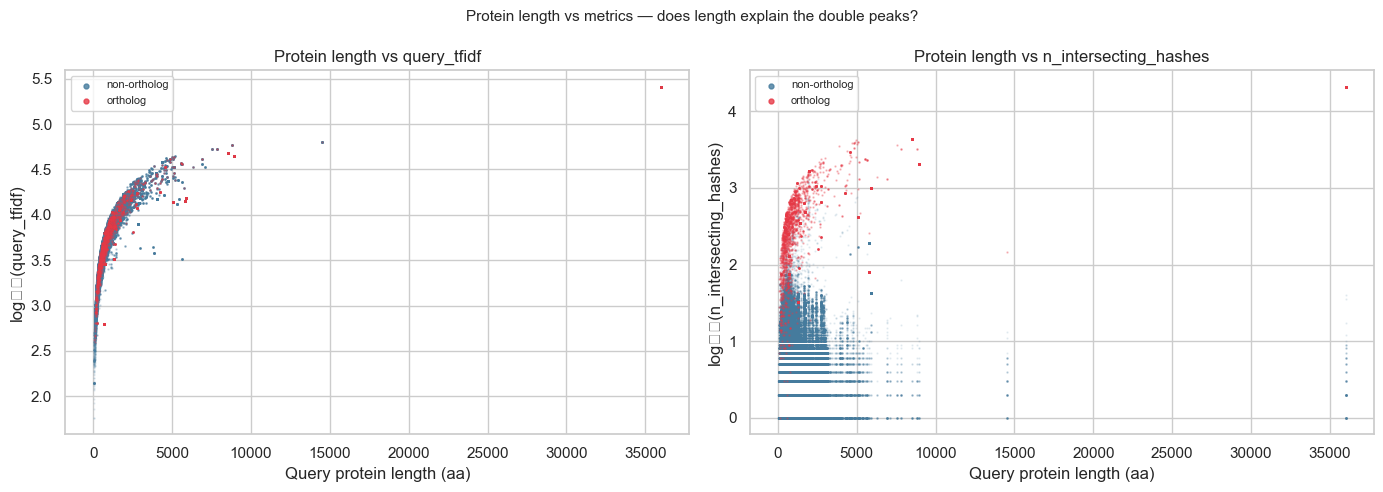

In [6]:
# Scatter: protein length vs n_intersecting_hashes, colored by ortholog status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

samp = df.sample(n=min(200_000, len(df)), random_state=RANDOM_SEED)

for ax, (col, label) in zip(axes, [
    ('query_tfidf', 'log₁₀(query_tfidf)'),
    ('n_intersecting_hashes', 'log₁₀(n_intersecting_hashes)'),
]):
    for is_orth, color, alpha in [(False, '#457b9d', 0.1), (True, '#e63946', 0.3)]:
        sub = samp[samp['is_ortholog'] == is_orth]
        ax.scatter(
            sub['query_len'],
            np.log10(sub[col].clip(lower=1e-20)),
            c=color, alpha=alpha, s=0.5,
            label='ortholog' if is_orth else 'non-ortholog'
        )
    ax.set_xlabel('Query protein length (aa)')
    ax.set_ylabel(label)
    ax.set_title(f'Protein length vs {col}')
    legend = ax.legend(markerscale=5, fontsize=8)
    for lh in legend.legend_handles:
        lh.set_alpha(0.8)

fig.suptitle('Protein length vs metrics — does length explain the double peaks?', fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_length_scatter.hp.k{KSIZE}.png', dpi=150)
plt.show()

### 3b. Are specific high-frequency k-mers driving the second peak?

The `moltype_seq` column contains the HP-encoded matched region. If certain HP patterns (e.g., all-hydrophobic runs) appear in the intersection and are very common in the proteome, they would inflate `sum_matched_kmer_freq` (and `prob_overlap`) even for non-orthologs.

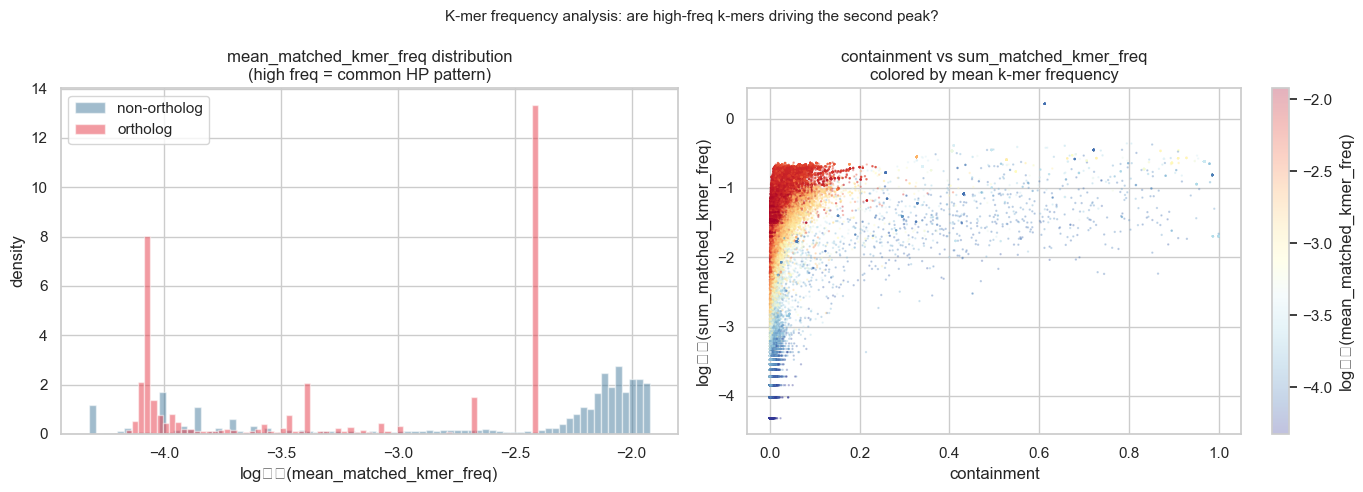

In [7]:
# Look at mean_matched_kmer_freq vs n_intersecting_hashes — high freq k-mers?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

samp_orth = df[df['is_ortholog']].sample(n=min(100_000, df['is_ortholog'].sum()), random_state=RANDOM_SEED)

# Panel 1: mean_matched_kmer_freq distribution
ax = axes[0]
for is_orth, color in [(False, '#457b9d'), (True, '#e63946')]:
    sub = df[df['is_ortholog'] == is_orth]['mean_matched_kmer_freq'].dropna()
    sub = sub.replace(0, np.nan).dropna()
    np.log10(sub).hist(ax=ax, bins=80, alpha=0.5, color=color,
                        label='ortholog' if is_orth else 'non-ortholog', density=True)
ax.set_xlabel('log₁₀(mean_matched_kmer_freq)')
ax.set_ylabel('density')
ax.set_title('mean_matched_kmer_freq distribution\n(high freq = common HP pattern)')
ax.legend()

# Panel 2: sum_matched_kmer_freq vs containment, colored by log(mean_freq)
ax = axes[1]
samp2 = df.sample(n=min(100_000, len(df)), random_state=RANDOM_SEED)
sc = ax.scatter(
    samp2['containment'],
    np.log10(samp2['sum_matched_kmer_freq'].clip(lower=1e-20)),
    c=np.log10(samp2['mean_matched_kmer_freq'].clip(lower=1e-20)),
    cmap='RdYlBu_r', alpha=0.3, s=0.5
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('log₁₀(mean_matched_kmer_freq)')
ax.set_xlabel('containment')
ax.set_ylabel('log₁₀(sum_matched_kmer_freq)')
ax.set_title('containment vs sum_matched_kmer_freq\ncolored by mean k-mer frequency')

fig.suptitle('K-mer frequency analysis: are high-freq k-mers driving the second peak?', fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_kmer_freq.hp.k{KSIZE}.png', dpi=150)
plt.show()

In [8]:
# Characterize the 'lower' peak in orthologs for query_tfidf:
# Orthologs with log10(query_tfidf) < 3.8 (approx threshold between peaks)
orth = df[df['is_ortholog']].copy()
tfidf_threshold = 10**3.8   # tune after seeing the histogram above

low_orth  = orth[orth['query_tfidf'] < tfidf_threshold]
high_orth = orth[orth['query_tfidf'] >= tfidf_threshold]

print(f"Ortholog pairs with low  tfidf (< {tfidf_threshold:.0f}): {len(low_orth):,}")
print(f"Ortholog pairs with high tfidf (≥ {tfidf_threshold:.0f}): {len(high_orth):,}")
print()
print("Low-tfidf orthologs — key metrics:")
print(low_orth[['query_len', 'n_intersecting_hashes', 'containment',
                'mean_matched_kmer_freq', 'expected_shared_kmers',
                'enrichment', 'region_length']]
      .describe(percentiles=[.1,.25,.5,.75,.9]).round(4))
print()
print("High-tfidf orthologs — key metrics:")
print(high_orth[['query_len', 'n_intersecting_hashes', 'containment',
                 'mean_matched_kmer_freq', 'expected_shared_kmers',
                 'enrichment', 'region_length']]
      .describe(percentiles=[.1,.25,.5,.75,.9]).round(4))

Ortholog pairs with low  tfidf (< 6310): 19,504
Ortholog pairs with high tfidf (≥ 6310): 14,821

Low-tfidf orthologs — key metrics:
        query_len  n_intersecting_hashes  containment  mean_matched_kmer_freq  \
count  19504.0000             19504.0000   19504.0000              19504.0000   
mean    1026.6438                95.2972       0.2127                  0.0027   
std      374.7211               113.6676       0.2639                  0.0016   
min       65.0000                 1.0000       0.0015                  0.0000   
10%      432.0000                32.0000       0.0541                  0.0001   
25%      721.7500                32.0000       0.0541                  0.0008   
50%     1301.0000                32.0000       0.0541                  0.0040   
75%     1301.0000               130.0000       0.3275                  0.0040   
90%     1301.0000               278.0000       0.6626                  0.0040   
max     1395.0000               662.0000       1.0000     

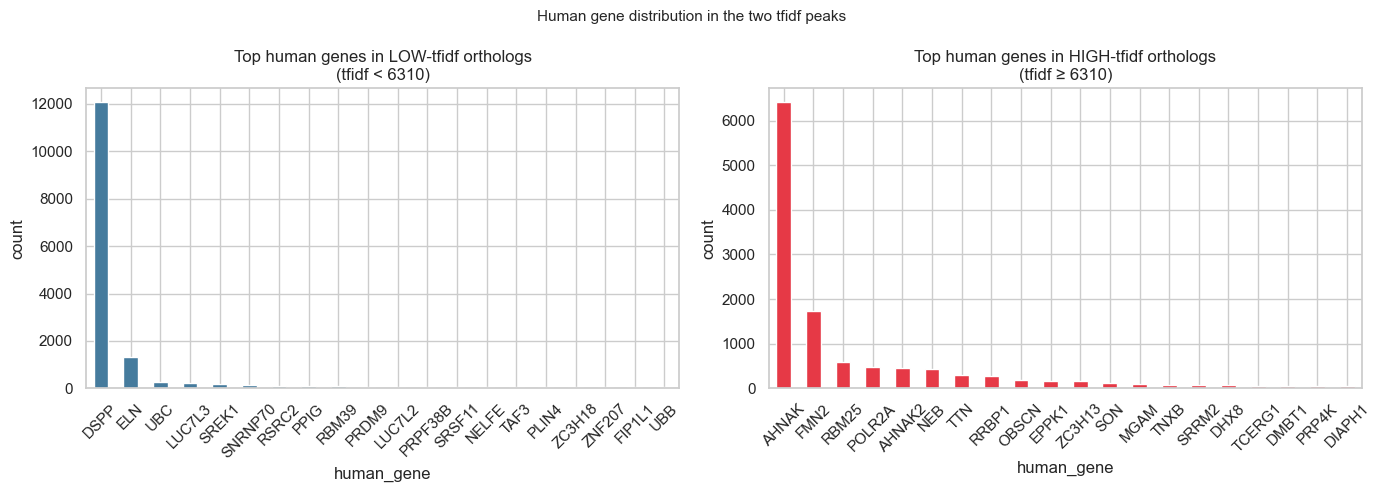

In [9]:
# What human genes are in the low-tfidf ortholog peak?
low_genes = low_orth['human_gene'].value_counts().head(20)
high_genes = high_orth['human_gene'].value_counts().head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
low_genes.plot(kind='bar', ax=axes[0], color='#457b9d')
axes[0].set_title(f'Top human genes in LOW-tfidf orthologs\n(tfidf < {tfidf_threshold:.0f})')
axes[0].set_ylabel('count')
axes[0].tick_params(axis='x', rotation=45)

high_genes.plot(kind='bar', ax=axes[1], color='#e63946')
axes[1].set_title(f'Top human genes in HIGH-tfidf orthologs\n(tfidf ≥ {tfidf_threshold:.0f})')
axes[1].set_ylabel('count')
axes[1].tick_params(axis='x', rotation=45)

fig.suptitle('Human gene distribution in the two tfidf peaks', fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_double_peak_genes.hp.k{KSIZE}.png', dpi=150)
plt.show()

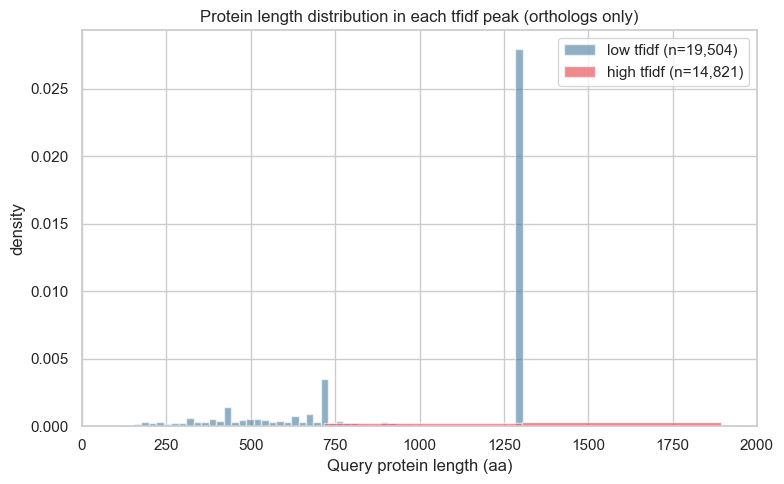

In [10]:
# Are the low-tfidf orthologs mostly short proteins?
fig, ax = plt.subplots(figsize=(8, 5))
low_orth['query_len'].hist(ax=ax, bins=60, alpha=0.6, color='#457b9d',
                           label=f'low tfidf (n={len(low_orth):,})', density=True)
high_orth['query_len'].hist(ax=ax, bins=60, alpha=0.6, color='#e63946',
                            label=f'high tfidf (n={len(high_orth):,})', density=True)
ax.set_xlabel('Query protein length (aa)')
ax.set_ylabel('density')
ax.set_title('Protein length distribution in each tfidf peak (orthologs only)')
ax.legend()
ax.set_xlim(0, 2000)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_peak_protein_lengths.hp.k{KSIZE}.png', dpi=150)
plt.show()

### 3c. HP sequence patterns in matched regions

Are the low-tfidf ortholog matches dominated by low-complexity or all-hydrophobic HP sequences?

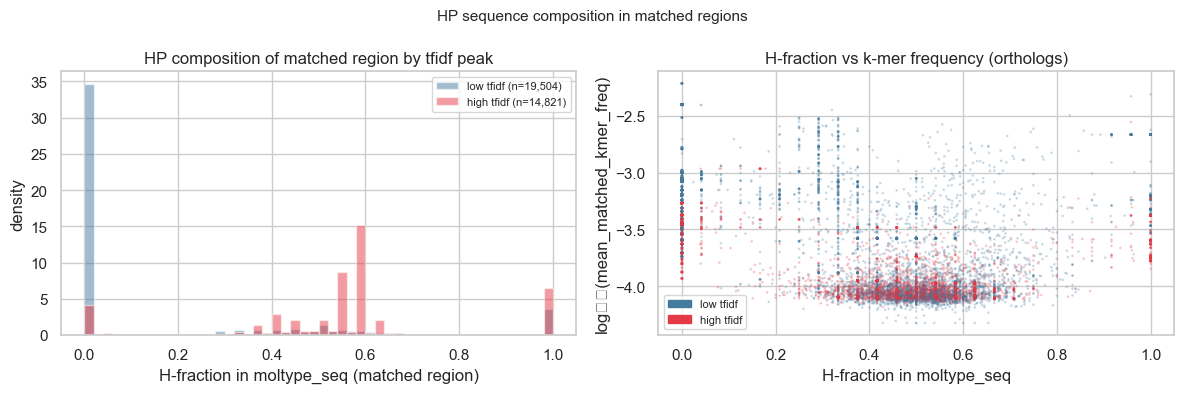

In [11]:
# HP composition of matched regions
def hp_h_fraction(seq):
    """Fraction of H (hydrophobic) residues in HP-encoded sequence."""
    if not isinstance(seq, str) or len(seq) == 0:
        return np.nan
    return seq.count('h') / len(seq)

# Compute on a subsample to keep it fast
orth_sub = orth.sample(n=min(50_000, len(orth)), random_state=RANDOM_SEED)
orth_sub = orth_sub.assign(
    h_frac = orth_sub['moltype_seq'].apply(hp_h_fraction),
    tfidf_low = orth_sub['query_tfidf'] < tfidf_threshold
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# H-fraction distribution
for low, color in [(True, '#457b9d'), (False, '#e63946')]:
    sub = orth_sub.loc[orth_sub['tfidf_low'] == low, 'h_frac'].dropna()
    label = 'low tfidf' if low else 'high tfidf'
    sub.hist(ax=axes[0], bins=50, alpha=0.5, color=color, label=f'{label} (n={len(sub):,})', density=True)
axes[0].set_xlabel('H-fraction in moltype_seq (matched region)')
axes[0].set_ylabel('density')
axes[0].set_title('HP composition of matched region by tfidf peak')
axes[0].legend(fontsize=8)

# Scatter: h_frac vs log10(mean_matched_kmer_freq)
axes[1].scatter(
    orth_sub['h_frac'],
    np.log10(orth_sub['mean_matched_kmer_freq'].clip(lower=1e-20)),
    c=np.where(orth_sub['tfidf_low'], '#457b9d', '#e63946'),
    alpha=0.2, s=1
)
axes[1].set_xlabel('H-fraction in moltype_seq')
axes[1].set_ylabel('log₁₀(mean_matched_kmer_freq)')
axes[1].set_title('H-fraction vs k-mer frequency (orthologs)')

# Legend patch
from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='#457b9d', label='low tfidf'),
    Patch(color='#e63946', label='high tfidf')
], fontsize=8)

fig.suptitle('HP sequence composition in matched regions', fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_hp_composition.hp.k{KSIZE}.png', dpi=150)
plt.show()

## 4. Poisson P-Value: Correct Calculation

### 4a. The existing `prob_overlap` is NOT a p-value

From the Rust search code:
```rust
// prob_overlap = Σ freq_query[h] * freq_target[h]  for h in intersection
let prob_overlap = intersection.iter().map(|&h| {
    let fq = qfreqs[h] / total_queries;
    let ft = kmer_freqs[h] / total_targets;
    fq * ft
}).sum();
```

This is a **joint k-mer frequency score**, bounded roughly by `sum_matched_kmer_freq / total_queries`. It is **not** a statistical p-value.

### 4b. Correct Poisson p-value
$$p = P(X \geq k \mid \lambda) = \text{Poisson.sf}(k-1, \lambda)$$
where $k = $ `n_intersecting_hashes` and $\lambda = $ `expected_shared_kmers`.

In [12]:
# ── Compute Poisson p-value ──────────────────────────────────────────────────
valid = df[['n_intersecting_hashes', 'expected_shared_kmers',
            'prob_overlap', 'enrichment', 'query_tfidf', 'containment',
            'region_length', 'is_ortholog', 'query_len']].copy()
valid = valid.dropna(subset=['n_intersecting_hashes', 'expected_shared_kmers'])

lam = valid['expected_shared_kmers'].values.copy()
k   = valid['n_intersecting_hashes'].values.astype(int)
lam = np.where(lam <= 0, 1e-300, lam)   # guard against zero/negative

poisson_p = _poisson.sf(k - 1, lam)      # P(X >= k)
poisson_p = np.clip(poisson_p, 1e-300, 1.0)
valid['poisson_p'] = poisson_p

# ── BH correction ────────────────────────────────────────────────────────────
n_v = len(valid)
sort_idx = np.argsort(poisson_p)
p_sorted = poisson_p[sort_idx]
ranks    = np.arange(1, n_v + 1)
bh_raw   = np.minimum(1.0, p_sorted * n_v / ranks)
p_bh_s   = np.minimum.accumulate(bh_raw[::-1])[::-1]
p_bh_out = np.empty_like(poisson_p)
p_bh_out[sort_idx] = p_bh_s

valid['poisson_p_bh']   = np.clip(p_bh_out, 1e-300, 1.0)
valid['poisson_p_bonf'] = np.clip(poisson_p * n_v, 1e-300, 1.0)

# ── Summary stats ────────────────────────────────────────────────────────────
n_sig_raw  = (valid['poisson_p']      < ALPHA).sum()
n_sig_bh   = (valid['poisson_p_bh']   < ALPHA).sum()
n_sig_hc   = (valid['poisson_p_bh']   < HIGH_CONF).sum()
n_sig_bonf = (valid['poisson_p_bonf'] < ALPHA).sum()

print(f"Sample size:                    {n_v:>10,}")
print(f"Poisson raw    p < {ALPHA}: {n_sig_raw:>10,}  ({n_sig_raw/n_v*100:.2f}%)")
print(f"Poisson BH     p < {ALPHA}: {n_sig_bh:>10,}  ({n_sig_bh/n_v*100:.2f}%)")
print(f"Poisson BH HC  p < {HIGH_CONF}: {n_sig_hc:>10,}  ({n_sig_hc/n_v*100:.2f}%)")
print(f"Poisson Bonf   p < {ALPHA}: {n_sig_bonf:>10,}  ({n_sig_bonf/n_v*100:.2f}%)")
print()
print("Poisson p summary:")
print(valid[['poisson_p', 'poisson_p_bh', 'poisson_p_bonf']]
      .describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).to_string(float_format='{:.3e}'.format))

Sample size:                       939,282
Poisson raw    p < 0.05:    862,976  (91.88%)
Poisson BH     p < 0.05:    857,564  (91.30%)
Poisson BH HC  p < 1e-05:    589,550  (62.77%)
Poisson Bonf   p < 0.05:    498,344  (53.06%)

Poisson p summary:
       poisson_p  poisson_p_bh  poisson_p_bonf
count  9.393e+05     9.393e+05       9.393e+05
mean   1.216e-02     1.271e-02       4.310e-01
std    4.205e-02     4.277e-02       4.841e-01
min   1.000e-300    4.361e-299      9.393e-295
1%    1.000e-300    4.361e-299      9.393e-295
5%     3.740e-59     7.480e-58       3.513e-53
25%    1.915e-19     7.657e-19       1.798e-13
50%    1.378e-08     2.756e-08       1.294e-02
75%    2.780e-04     3.706e-04       1.000e+00
95%    8.275e-02     8.710e-02       1.000e+00
99%    2.120e-01     2.142e-01       1.000e+00
max    9.115e-01     9.115e-01       1.000e+00


In [13]:
# Breakdown by ortholog status
for is_orth in [True, False]:
    sub = valid[valid['is_ortholog'] == is_orth]
    label = 'ORTHOLOGS' if is_orth else 'NON-ORTHOLOGS'
    n = len(sub)
    n_bh = (sub['poisson_p_bh'] < ALPHA).sum()
    n_hc = (sub['poisson_p_bh'] < HIGH_CONF).sum()
    print(f"{label} (n={n:,}):")
    print(f"  BH sig (p_bh < {ALPHA}): {n_bh:,}  ({n_bh/n*100:.1f}%)")
    print(f"  HC sig (p_bh < {HIGH_CONF}): {n_hc:,}  ({n_hc/n*100:.1f}%)")
    print(f"  median poisson_p: {sub['poisson_p'].median():.3e}")
    print()

ORTHOLOGS (n=34,325):
  BH sig (p_bh < 0.05): 34,325  (100.0%)
  HC sig (p_bh < 1e-05): 34,296  (99.9%)
  median poisson_p: 1.000e-300

NON-ORTHOLOGS (n=904,957):
  BH sig (p_bh < 0.05): 823,239  (91.0%)
  HC sig (p_bh < 1e-05): 555,254  (61.4%)
  median poisson_p: 2.758e-08



### 4c. Distribution of Poisson p-values

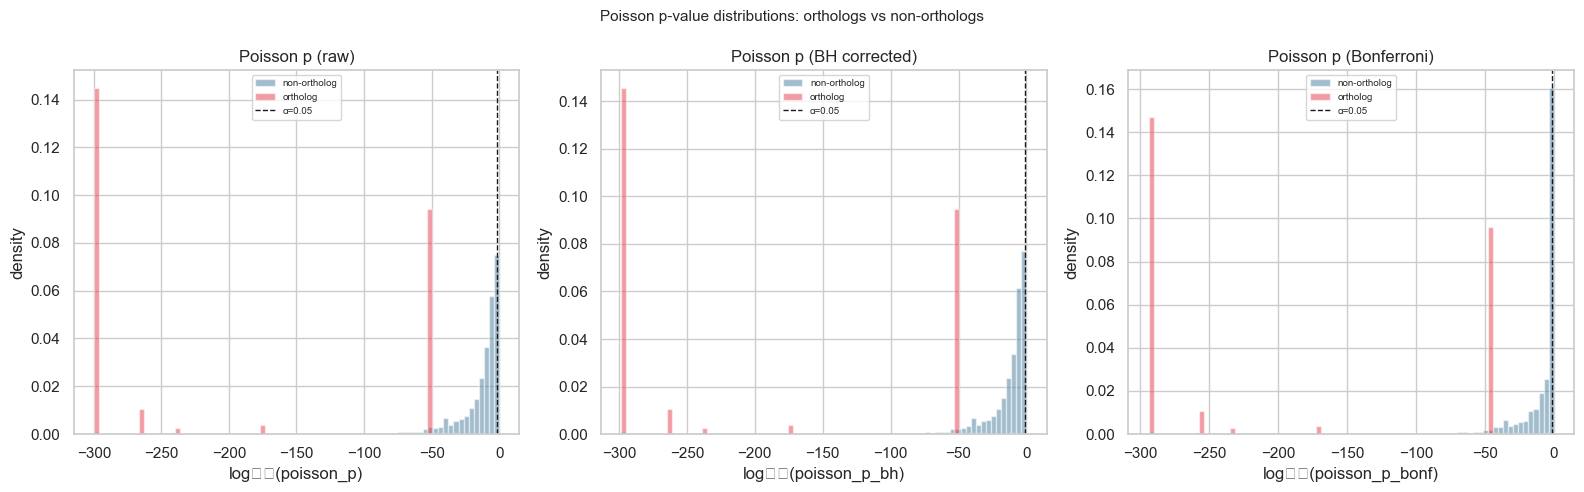

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pval_cols = [
    ('poisson_p',      'Poisson p (raw)'),
    ('poisson_p_bh',   'Poisson p (BH corrected)'),
    ('poisson_p_bonf', 'Poisson p (Bonferroni)'),
]

for ax, (col, label) in zip(axes, pval_cols):
    for is_orth, color in [(False, '#457b9d'), (True, '#e63946')]:
        sub = valid.loc[valid['is_ortholog'] == is_orth, col].replace(0, np.nan).dropna()
        np.log10(sub).hist(ax=ax, bins=80, alpha=0.5, color=color,
                           label='ortholog' if is_orth else 'non-ortholog', density=True)
    ax.axvline(np.log10(ALPHA), color='k', linestyle='--', linewidth=1, label=f'α={ALPHA}')
    ax.set_xlabel(f'log₁₀({col})')
    ax.set_ylabel('density')
    ax.set_title(label)
    ax.legend(fontsize=7)

fig.suptitle('Poisson p-value distributions: orthologs vs non-orthologs', fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_poisson_pvals.hp.k{KSIZE}.png', dpi=150)
plt.show()

### 4d. Compare prob_overlap vs Poisson p-value for ortholog discrimination

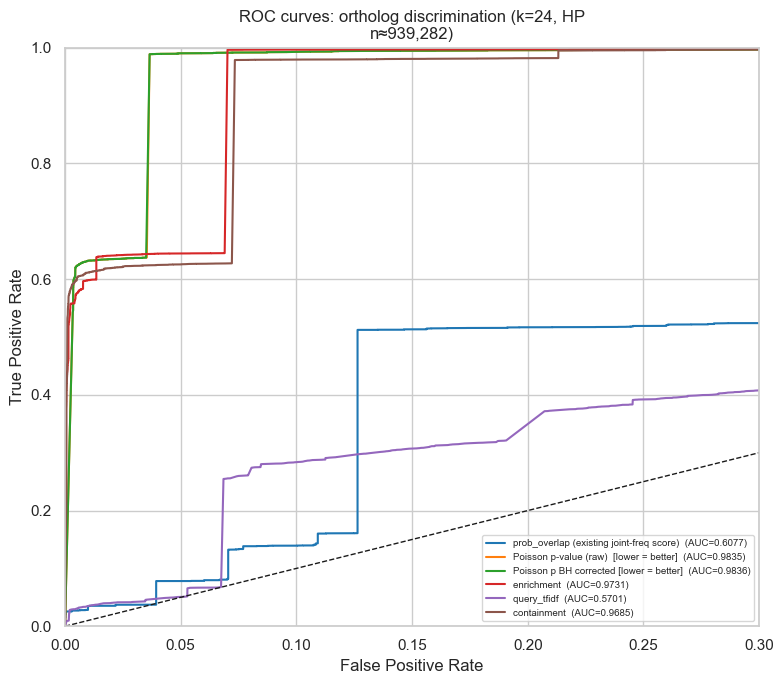

In [15]:
# ROC curves: which metric best separates orthologs from non-orthologs?
from sklearn.metrics import roc_curve, auc

y_true = valid['is_ortholog'].astype(int).values

metrics_roc = [
    # (column, higher_is_better, label)
    ('prob_overlap',    True,  'prob_overlap (existing joint-freq score)'),
    ('poisson_p',       False, 'Poisson p-value (raw)  [lower = better]'),
    ('poisson_p_bh',    False, 'Poisson p BH corrected [lower = better]'),
    ('enrichment',      True,  'enrichment'),
    ('query_tfidf',     True,  'query_tfidf'),
    ('containment',     True,  'containment'),
]

fig, ax = plt.subplots(figsize=(8, 7))
palette = sns.color_palette('tab10', n_colors=len(metrics_roc))

for (col, higher_better, label), color in zip(metrics_roc, palette):
    vals = valid[col].replace([np.inf, -np.inf], np.nan).fillna(0)
    scores = vals.values if higher_better else -vals.values
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{label}  (AUC={roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC curves: ortholog discrimination (k={KSIZE}, HP\nn≈{n_v:,})')
ax.legend(fontsize=7, loc='lower right')
ax.set_xlim(0, 0.3)  # zoom into low-FPR region
ax.set_ylim(0, 1)

fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_roc_comparison.hp.k{KSIZE}.png', dpi=150)
plt.show()

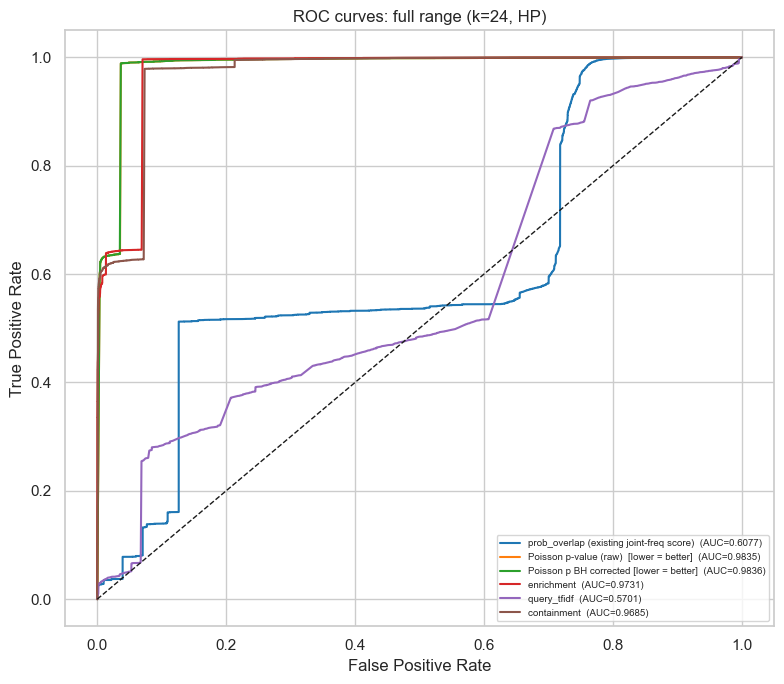

In [16]:
# Full-range ROC curves
fig, ax = plt.subplots(figsize=(8, 7))

for (col, higher_better, label), color in zip(metrics_roc, palette):
    vals = valid[col].replace([np.inf, -np.inf], np.nan).fillna(0)
    scores = vals.values if higher_better else -vals.values
    fpr, tpr, _ = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{label}  (AUC={roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC curves: full range (k={KSIZE}, HP)')
ax.legend(fontsize=7, loc='lower right')

fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_roc_comparison_full.hp.k{KSIZE}.png', dpi=150)
plt.show()

## 5. Poisson p-value: how does it handle the double-peak?

The low-tfidf ortholog peak: are these orthologs with low `n_intersecting_hashes` relative to `expected_shared_kmers`, i.e., not significantly enriched?

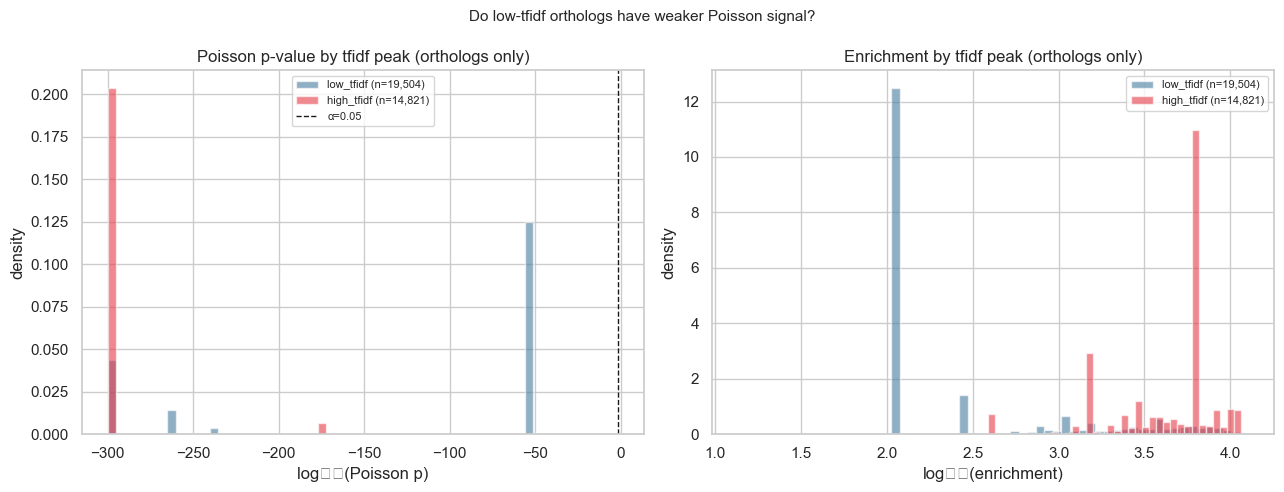

           query_len           n_intersecting_hashes           enrichment  \
              median      mean                median      mean     median   
peak                                                                        
high_tfidf    5795.0  4741.757                 993.0  1395.557   6316.308   
low_tfidf     1301.0  1026.644                  32.0    95.297    117.999   

                     poisson_p      region_length          
                mean    median mean        median    mean  
peak                                                       
high_tfidf  5198.695       0.0  0.0          24.0  31.423  
low_tfidf   1112.154       0.0  0.0          24.0  30.036  


In [17]:
orth_valid = valid[valid['is_ortholog']].copy()

# Assign tfidf peak group
orth_valid['peak'] = np.where(orth_valid['query_tfidf'] < tfidf_threshold, 'low_tfidf', 'high_tfidf')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Poisson p distribution by peak
ax = axes[0]
for peak, color in [('low_tfidf', '#457b9d'), ('high_tfidf', '#e63946')]:
    sub = orth_valid.loc[orth_valid['peak'] == peak, 'poisson_p'].replace(0, np.nan).dropna()
    np.log10(sub).hist(ax=ax, bins=60, alpha=0.6, color=color,
                       label=f'{peak} (n={len(sub):,})', density=True)
ax.axvline(np.log10(ALPHA), color='k', ls='--', lw=1, label=f'α={ALPHA}')
ax.set_xlabel('log₁₀(Poisson p)')
ax.set_ylabel('density')
ax.set_title('Poisson p-value by tfidf peak (orthologs only)')
ax.legend(fontsize=8)

# Enrichment by peak
ax = axes[1]
for peak, color in [('low_tfidf', '#457b9d'), ('high_tfidf', '#e63946')]:
    sub = orth_valid.loc[orth_valid['peak'] == peak, 'enrichment'].replace(0, np.nan).dropna()
    np.log10(sub).hist(ax=ax, bins=60, alpha=0.6, color=color,
                       label=f'{peak} (n={len(sub):,})', density=True)
ax.set_xlabel('log₁₀(enrichment)')
ax.set_ylabel('density')
ax.set_title('Enrichment by tfidf peak (orthologs only)')
ax.legend(fontsize=8)

fig.suptitle('Do low-tfidf orthologs have weaker Poisson signal?', fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_peak_poisson.hp.k{KSIZE}.png', dpi=150)
plt.show()

# Summary table
print(orth_valid.groupby('peak')[['query_len', 'n_intersecting_hashes',
                                   'enrichment', 'poisson_p', 'region_length']]
      .agg(['median', 'mean']).round(3))

## 6. Summary & Quantile Analysis

In [18]:
cols_q = ['prob_overlap', 'enrichment', 'poisson_p', 'poisson_p_bh', 'poisson_p_bonf']
pcts   = [0.001, 0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999, 1.0]

qt = valid[cols_q].quantile(pcts)
qt.index = [f"{p*100:.1f}%" for p in pcts]

qt_log = qt[['prob_overlap', 'poisson_p', 'poisson_p_bh', 'poisson_p_bonf']].apply(np.log10)
qt_log.columns = [f'log10({c})' for c in qt_log.columns]

print("=== Quantiles ===")
print(qt.to_string(float_format='{:.3e}'.format))
print()
print("=== log10 of probability columns ===")
print(qt_log.to_string(float_format='{:.2f}'.format))
print()

for col in ['prob_overlap', 'enrichment', 'poisson_p']:
    v = valid[col].dropna()
    print(f"{col}: min={v.min():.3e}  median={v.median():.3e}  max={v.max():.3e}")

=== Quantiles ===
        prob_overlap  enrichment  poisson_p  poisson_p_bh  poisson_p_bonf
0.1%       2.408e-09   1.989e+00 1.000e-300    4.361e-299      9.393e-295
1.0%       4.816e-09   4.074e+00 1.000e-300    4.361e-299      9.393e-295
5.0%       9.631e-09   9.014e+00  3.740e-59     7.480e-58       3.513e-53
10.0%      2.167e-08   1.265e+01  1.234e-42     1.234e-41       1.160e-36
25.0%      2.124e-06   2.218e+01  1.915e-19     7.657e-19       1.798e-13
50.0%      5.346e-04   3.959e+01  1.378e-08     2.756e-08       1.294e-02
75.0%      8.703e-04   7.013e+01  2.780e-04     3.706e-04       1.000e+00
90.0%      1.238e-03   1.180e+02  3.652e-02     4.057e-02       1.000e+00
95.0%      1.529e-03   1.955e+02  8.275e-02     8.710e-02       1.000e+00
99.0%      1.680e-03   6.316e+03  2.120e-01     2.142e-01       1.000e+00
99.9%      1.747e-03   9.728e+03  3.908e-01     3.912e-01       1.000e+00
100.0%     2.205e-03   1.754e+04  9.115e-01     9.115e-01       1.000e+00

=== log10 of probab

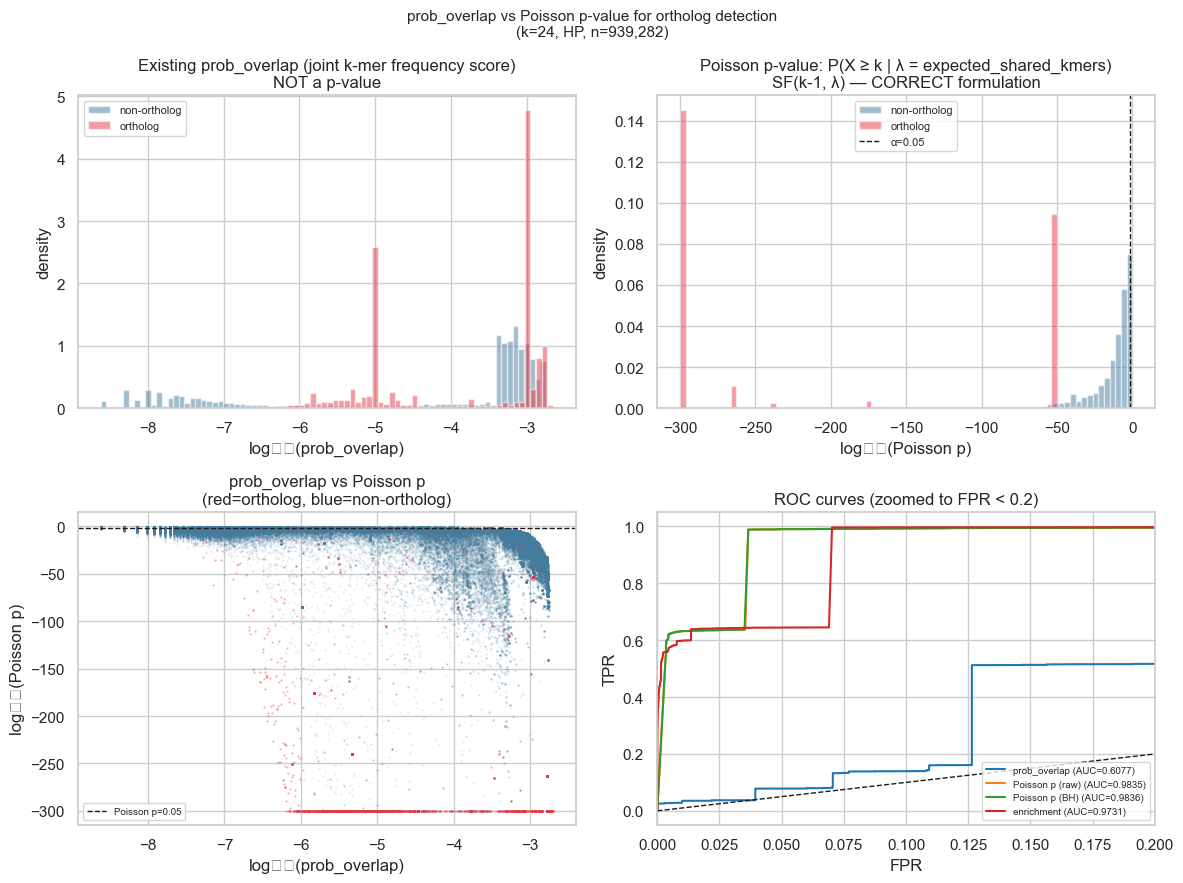

In [19]:
# Final summary figure: existing prob_overlap vs Poisson p-value
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. prob_overlap (existing) distribution
ax = axes[0, 0]
for is_orth, color in [(False, '#457b9d'), (True, '#e63946')]:
    sub = valid.loc[valid['is_ortholog'] == is_orth, 'prob_overlap'].replace(0, np.nan).dropna()
    np.log10(sub).hist(ax=ax, bins=80, alpha=0.5, color=color,
                       label='ortholog' if is_orth else 'non-ortholog', density=True)
ax.set_title('Existing prob_overlap (joint k-mer frequency score)\nNOT a p-value')
ax.set_xlabel('log₁₀(prob_overlap)')
ax.set_ylabel('density')
ax.legend(fontsize=8)

# 2. Poisson p-value distribution
ax = axes[0, 1]
for is_orth, color in [(False, '#457b9d'), (True, '#e63946')]:
    sub = valid.loc[valid['is_ortholog'] == is_orth, 'poisson_p'].replace(0, np.nan).dropna()
    np.log10(sub).hist(ax=ax, bins=80, alpha=0.5, color=color,
                       label='ortholog' if is_orth else 'non-ortholog', density=True)
ax.axvline(np.log10(ALPHA), color='k', ls='--', lw=1, label=f'α={ALPHA}')
ax.set_title('Poisson p-value: P(X ≥ k | λ = expected_shared_kmers)\nSF(k-1, λ) — CORRECT formulation')
ax.set_xlabel('log₁₀(Poisson p)')
ax.set_ylabel('density')
ax.legend(fontsize=8)

# 3. Scatter: prob_overlap vs Poisson p
ax = axes[1, 0]
samp3 = valid.sample(n=min(200_000, len(valid)), random_state=RANDOM_SEED)
for is_orth, color, alpha in [(False, '#457b9d', 0.1), (True, '#e63946', 0.3)]:
    sub = samp3[samp3['is_ortholog'] == is_orth]
    ax.scatter(
        np.log10(sub['prob_overlap'].clip(lower=1e-20)),
        np.log10(sub['poisson_p'].clip(lower=1e-300)),
        c=color, alpha=alpha, s=0.5
    )
ax.set_xlabel('log₁₀(prob_overlap)')
ax.set_ylabel('log₁₀(Poisson p)')
ax.set_title('prob_overlap vs Poisson p\n(red=ortholog, blue=non-ortholog)')
ax.axhline(np.log10(ALPHA), color='k', ls='--', lw=1, label=f'Poisson p={ALPHA}')
ax.legend(fontsize=7)

# 4. ROC comparison (zoomed)
ax = axes[1, 1]
roc_metrics = [
    ('prob_overlap', True, 'prob_overlap'),
    ('poisson_p', False, 'Poisson p (raw)'),
    ('poisson_p_bh', False, 'Poisson p (BH)'),
    ('enrichment', True, 'enrichment'),
]
pal4 = sns.color_palette('tab10', 4)
for (col, hb, label), color in zip(roc_metrics, pal4):
    vals = valid[col].replace([np.inf, -np.inf], np.nan).fillna(0)
    scores = vals.values if hb else -vals.values
    fpr, tpr, _ = roc_curve(valid['is_ortholog'].astype(int).values, scores)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{label} (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC curves (zoomed to FPR < 0.2)')
ax.set_xlim(0, 0.2)
ax.legend(fontsize=7, loc='lower right')

fig.suptitle(f'prob_overlap vs Poisson p-value for ortholog detection\n(k={KSIZE}, HP, n={n_v:,})', fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_poisson_vs_proboverlap.hp.k{KSIZE}.png', dpi=150)
plt.show()

In [20]:
print("\n=== SUMMARY ===")
print(f"Total rows analyzed: {n_v:,}")
print(f"  Orthologs:     {valid['is_ortholog'].sum():,}")
print(f"  Non-orthologs: {(~valid['is_ortholog']).sum():,}")
print()
print(f"Poisson p < {ALPHA} (raw):         {n_sig_raw:,} ({n_sig_raw/n_v*100:.1f}%)")
print(f"Poisson p_BH < {ALPHA}:            {n_sig_bh:,} ({n_sig_bh/n_v*100:.1f}%)")
print(f"Poisson p_BH < {HIGH_CONF} (HC):   {n_sig_hc:,} ({n_sig_hc/n_v*100:.1f}%)")
print()
print("NOTE: The existing 'prob_overlap' column is a joint k-mer frequency score,")
print("not a p-value. The Poisson SF formula gives proper statistical significance.")


=== SUMMARY ===
Total rows analyzed: 939,282
  Orthologs:     34,325
  Non-orthologs: 904,957

Poisson p < 0.05 (raw):         862,976 (91.9%)
Poisson p_BH < 0.05:            857,564 (91.3%)
Poisson p_BH < 1e-05 (HC):   589,550 (62.8%)

NOTE: The existing 'prob_overlap' column is a joint k-mer frequency score,
not a p-value. The Poisson SF formula gives proper statistical significance.


## 7. Pairwise Scatter Matrix: All Metrics vs Each Other

Each panel shows two metrics against each other; red = ortholog, blue = non-ortholog (subsample for speed).

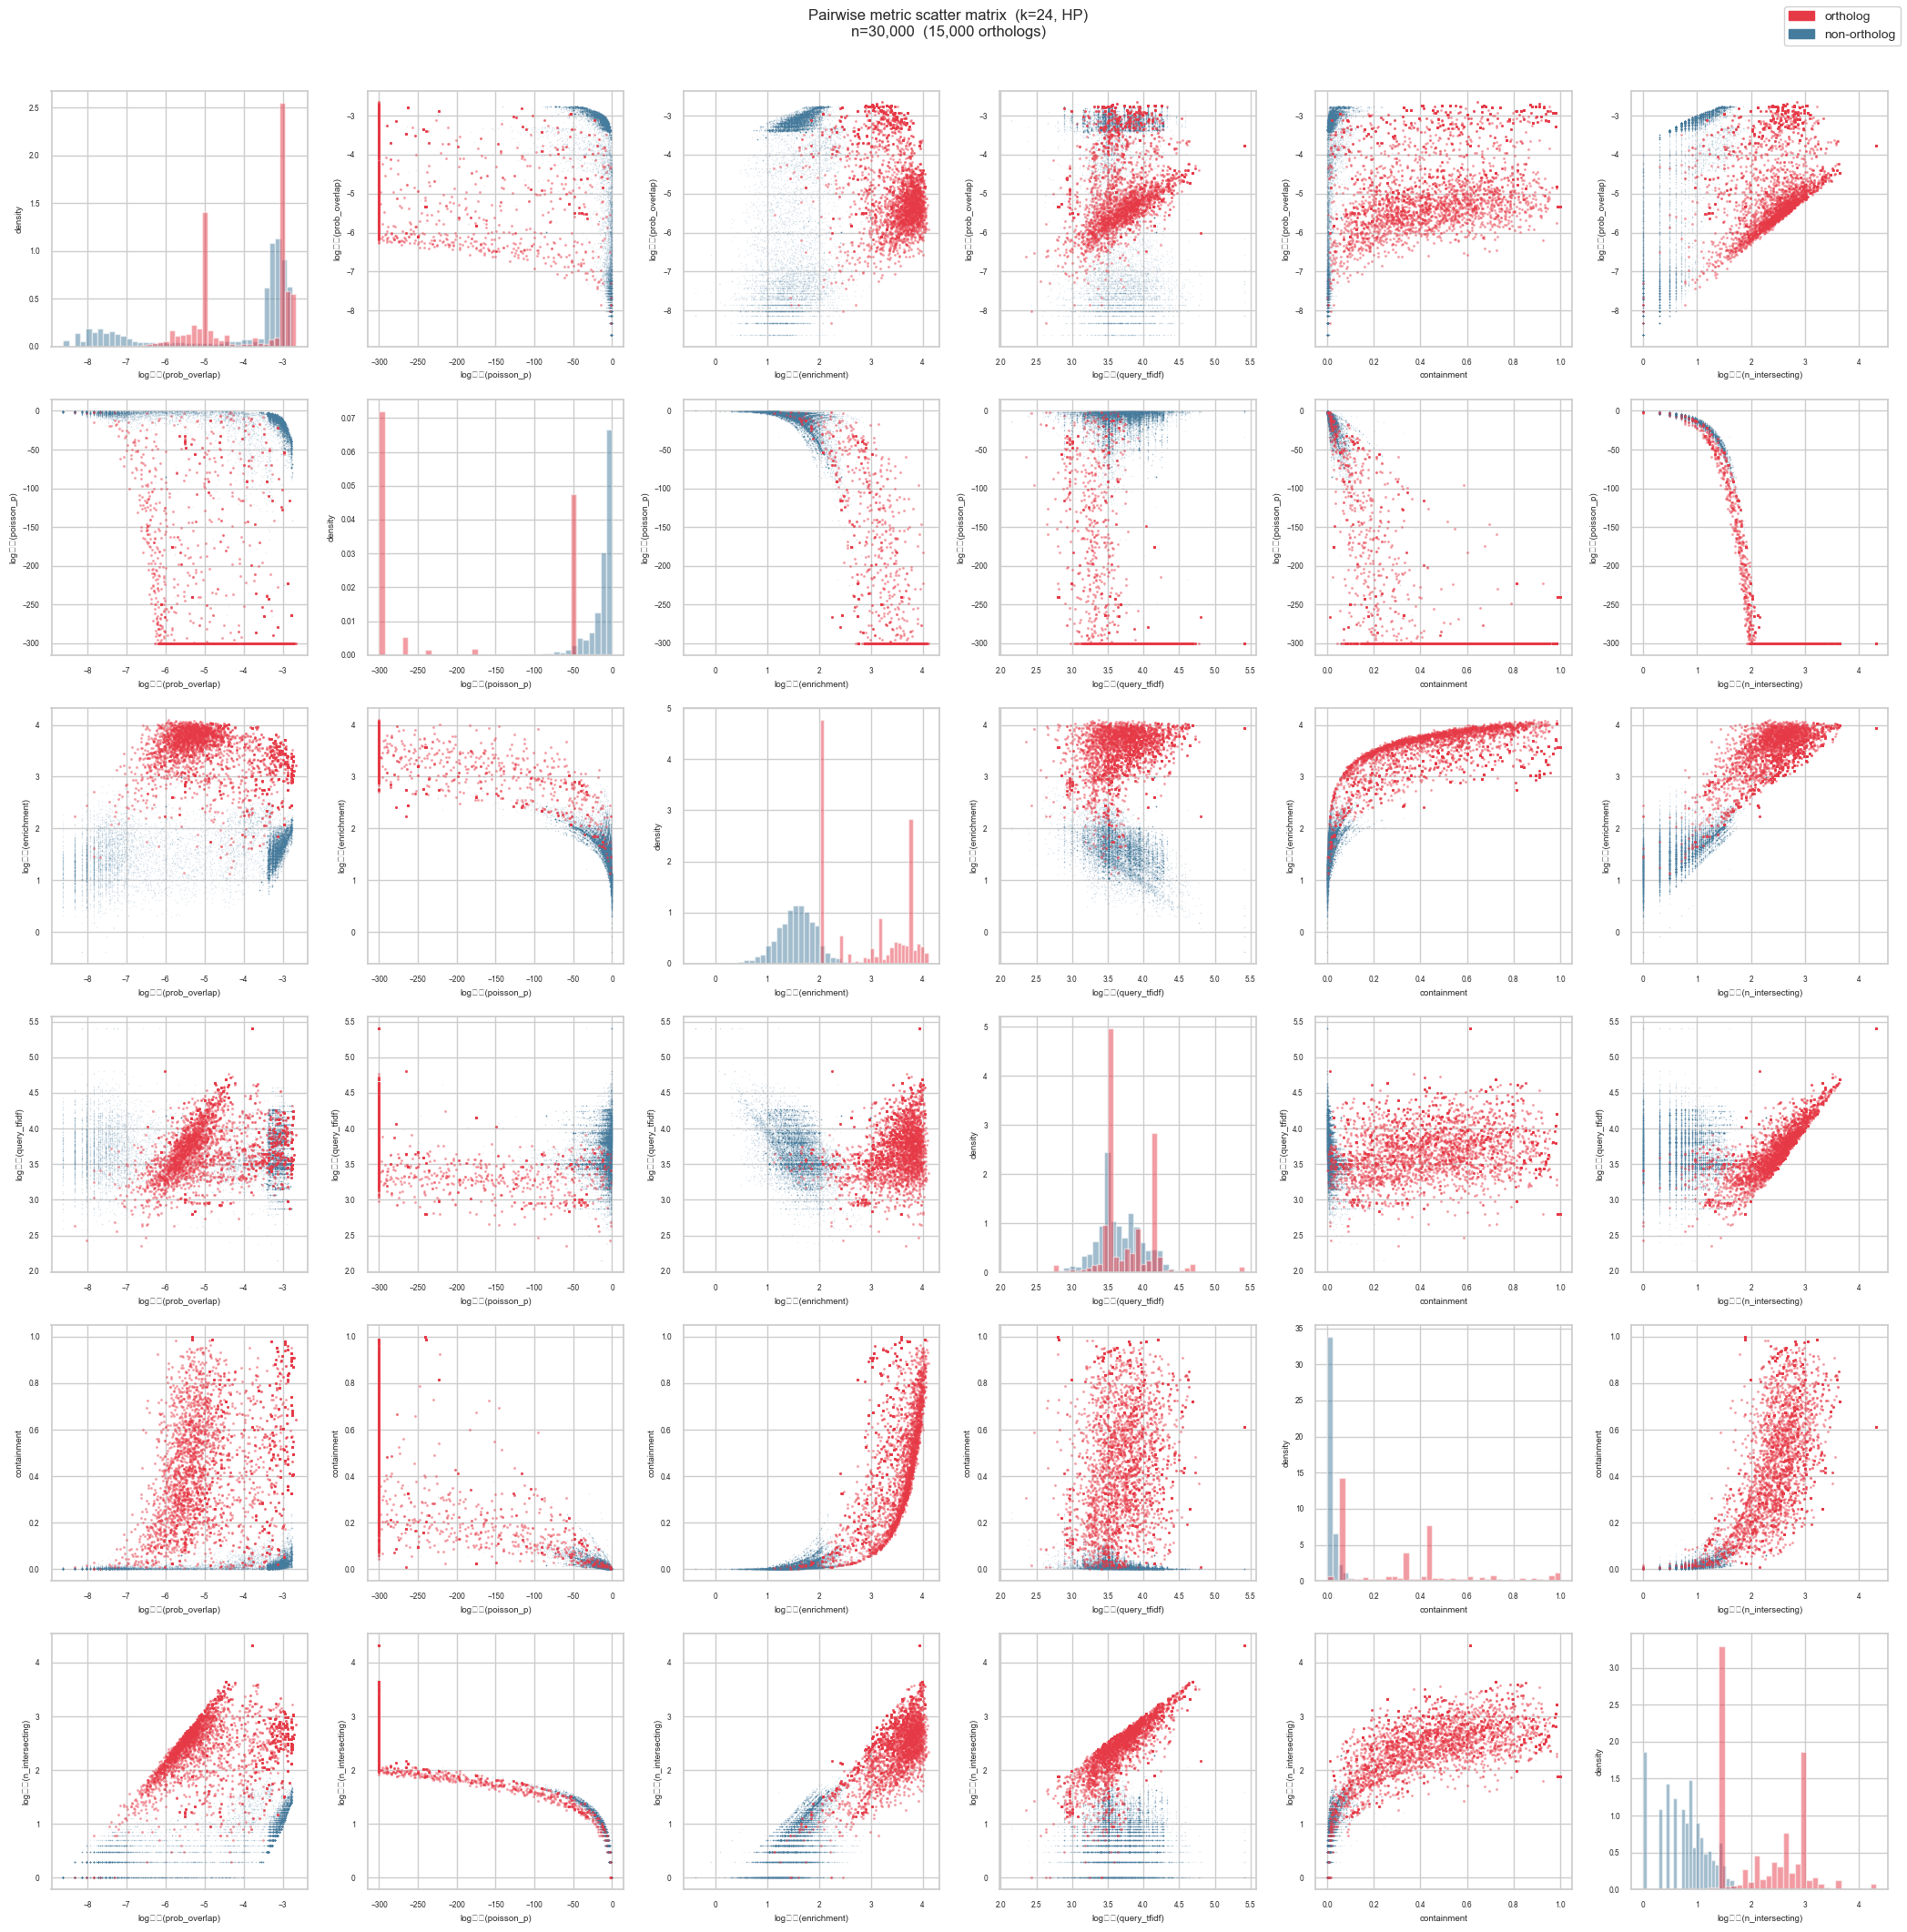

In [21]:
# ── Pairwise scatter matrix ───────────────────────────────────────────────────
# Metrics to compare; (column, display_label, log_transform)
PAIR_METRICS = [
    ('prob_overlap',  'log₁₀(prob_overlap)',  True),
    ('poisson_p',     'log₁₀(poisson_p)',     True),
    ('enrichment',    'log₁₀(enrichment)',    True),
    ('query_tfidf',   'log₁₀(query_tfidf)',   True),
    ('containment',   'containment',          False),
    ('n_intersecting_hashes', 'log₁₀(n_intersecting)', True),
]
N = len(PAIR_METRICS)

# Stratified subsample: 15k non-orthologs + all orthologs (up to 15k)
rng2 = np.random.default_rng(RANDOM_SEED + 1)
n_samp = 15_000
non_orth_idx = valid[~valid['is_ortholog']].sample(n=n_samp, random_state=RANDOM_SEED).index
orth_idx     = valid[ valid['is_ortholog']].sample(n=min(n_samp, valid['is_ortholog'].sum()),
                                                    random_state=RANDOM_SEED).index
pair_df = valid.loc[non_orth_idx.union(orth_idx)].copy()

# Build log-transformed columns
pair_log = {}
for col, label, do_log in PAIR_METRICS:
    vals = pair_df[col].replace(0, np.nan).clip(lower=1e-300)
    pair_log[label] = np.log10(vals) if do_log else pair_df[col]

pair_plot_df = pd.DataFrame(pair_log)
pair_plot_df['is_ortholog'] = pair_df['is_ortholog'].values

COLORS = {True: '#e63946', False: '#457b9d'}

fig, axes = plt.subplots(N, N, figsize=(3.5 * N, 3.5 * N))

for row, (ycol, ylabel, _) in enumerate(PAIR_METRICS):
    for col, (xcol, xlabel, _) in enumerate(PAIR_METRICS):
        ax = axes[row, col]

        if row == col:
            # Diagonal: KDE / histogram of the single metric
            for is_orth, color in [(False, '#457b9d'), (True, '#e63946')]:
                sub = pair_plot_df.loc[pair_plot_df['is_ortholog'] == is_orth, xlabel].dropna()
                sub.hist(ax=ax, bins=40, alpha=0.5, color=color, density=True)
            ax.set_xlabel(xlabel, fontsize=7)
            ax.set_ylabel('density', fontsize=7)
        else:
            # Off-diagonal: scatter, non-orthologs first (behind), orthologs on top
            for is_orth, color, alpha, sz in [(False, '#457b9d', 0.15, 1), (True, '#e63946', 0.5, 4)]:
                sub = pair_plot_df[pair_plot_df['is_ortholog'] == is_orth]
                ax.scatter(sub[xlabel], sub[ylabel], c=color, alpha=alpha, s=sz, linewidths=0)
            ax.set_xlabel(xlabel, fontsize=7)
            ax.set_ylabel(ylabel, fontsize=7)

        ax.tick_params(labelsize=6)

# Legend in corner
from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(color='#e63946', label='ortholog'), Patch(color='#457b9d', label='non-ortholog')],
    loc='upper right', fontsize=10, framealpha=0.9
)
fig.suptitle(
    f'Pairwise metric scatter matrix  (k={KSIZE}, HP)\n'
    f'n={len(pair_plot_df):,}  ({pair_plot_df["is_ortholog"].sum():,} orthologs)',
    fontsize=12, y=1.01
)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_pairwise_scatter.hp.k{KSIZE}.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. ROC Curves and AUC Across All K-Sizes (k=24–30)

For each ksize, we load a 5% sample, compute Poisson p-values + BH correction, then evaluate all metrics.

In [22]:
def load_ksize(ksize, sample_frac=0.05, seed=42, chunk=500_000):
    """Load a sampled ortholog-evaluation TSV for a given ksize and compute Poisson p-values."""
    path = f"{DATA_DIR}/ortholog_evaluation.hp.k{ksize}.tsv"
    rng_k = np.random.default_rng(seed)
    parts = []
    cols = ['n_intersecting_hashes', 'expected_shared_kmers', 'prob_overlap',
            'enrichment', 'query_tfidf', 'containment', 'is_ortholog']
    for chunk_df in pd.read_csv(path, sep='\t', chunksize=chunk, usecols=cols):
        mask = rng_k.random(len(chunk_df)) < sample_frac
        parts.append(chunk_df[mask])
    df_k = pd.concat(parts, ignore_index=True)

    # Compute Poisson p + BH correction
    lam = df_k['expected_shared_kmers'].values.copy()
    k   = df_k['n_intersecting_hashes'].values.astype(int)
    lam = np.where(lam <= 0, 1e-300, lam)
    pp  = _poisson.sf(k - 1, lam)
    pp  = np.clip(pp, 1e-300, 1.0)

    n = len(df_k)
    sidx   = np.argsort(pp)
    bh_raw = np.minimum(1.0, pp[sidx] * n / np.arange(1, n + 1))
    bh_s   = np.minimum.accumulate(bh_raw[::-1])[::-1]
    bh_out = np.empty_like(pp)
    bh_out[sidx] = bh_s

    df_k['poisson_p']    = pp
    df_k['poisson_p_bh'] = np.clip(bh_out, 1e-300, 1.0)
    return df_k

KSIZES = [24, 25, 26, 27, 28, 29, 30]
data_by_ksize = {}
for ks in KSIZES:
    print(f"Loading k={ks}…", end=' ', flush=True)
    data_by_ksize[ks] = load_ksize(ks)
    d = data_by_ksize[ks]
    print(f"{len(d):,} rows  ({d['is_ortholog'].sum():,} orthologs)")

Loading k=24… 

939,282 rows  (34,325 orthologs)
Loading k=25… 

680,341 rows  (32,578 orthologs)
Loading k=26… 

515,249 rows  (31,007 orthologs)
Loading k=27… 

404,524 rows  (29,269 orthologs)
Loading k=28… 

325,368 rows  (28,255 orthologs)
Loading k=29… 

270,048 rows  (27,364 orthologs)
Loading k=30… 

228,506 rows  (26,067 orthologs)


In [23]:
# ── Compute AUC for every metric × ksize ─────────────────────────────────────
ROC_METRICS = [
    ('prob_overlap',  True,  'prob_overlap (joint-freq, existing)'),
    ('poisson_p',     False, 'Poisson p (raw)'),
    ('poisson_p_bh',  False, 'Poisson p BH-corrected'),
    ('enrichment',    True,  'enrichment'),
    ('query_tfidf',   True,  'query_tfidf'),
    ('containment',   True,  'containment'),
]
ROC_PAL = sns.color_palette('tab10', n_colors=len(ROC_METRICS))

auc_records = []   # (ksize, metric_label, auc_value)
roc_curves  = {}   # (ksize, metric_label) → (fpr, tpr, auc_val)

for ks, df_k in data_by_ksize.items():
    y = df_k['is_ortholog'].astype(int).values
    for (col, hb, label), color in zip(ROC_METRICS, ROC_PAL):
        if col not in df_k.columns:
            continue
        vals = df_k[col].replace([np.inf, -np.inf], np.nan).fillna(0)
        scores = vals.values if hb else -vals.values
        fpr, tpr, _ = roc_curve(y, scores)
        auc_val = auc(fpr, tpr)
        auc_records.append({'ksize': ks, 'metric': label, 'AUC': auc_val})
        roc_curves[(ks, label)] = (fpr, tpr, auc_val)

auc_df = pd.DataFrame(auc_records)
print(auc_df.pivot(index='ksize', columns='metric', values='AUC').round(4).to_string())

metric  Poisson p (raw)  Poisson p BH-corrected  containment  enrichment  prob_overlap (joint-freq, existing)  query_tfidf
ksize                                                                                                                     
24               0.9835                  0.9836       0.9685      0.9731                               0.6077       0.5701
25               0.9726                  0.9726       0.9572      0.9592                               0.5676       0.5307
26               0.9514                  0.9514       0.9376      0.9329                               0.5249       0.4980
27               0.9306                  0.9307       0.9168      0.9026                               0.4881       0.4802
28               0.9116                  0.9116       0.8986      0.8752                               0.4557       0.4704
29               0.8802                  0.8802       0.8642      0.8283                               0.4422       0.4638
30              

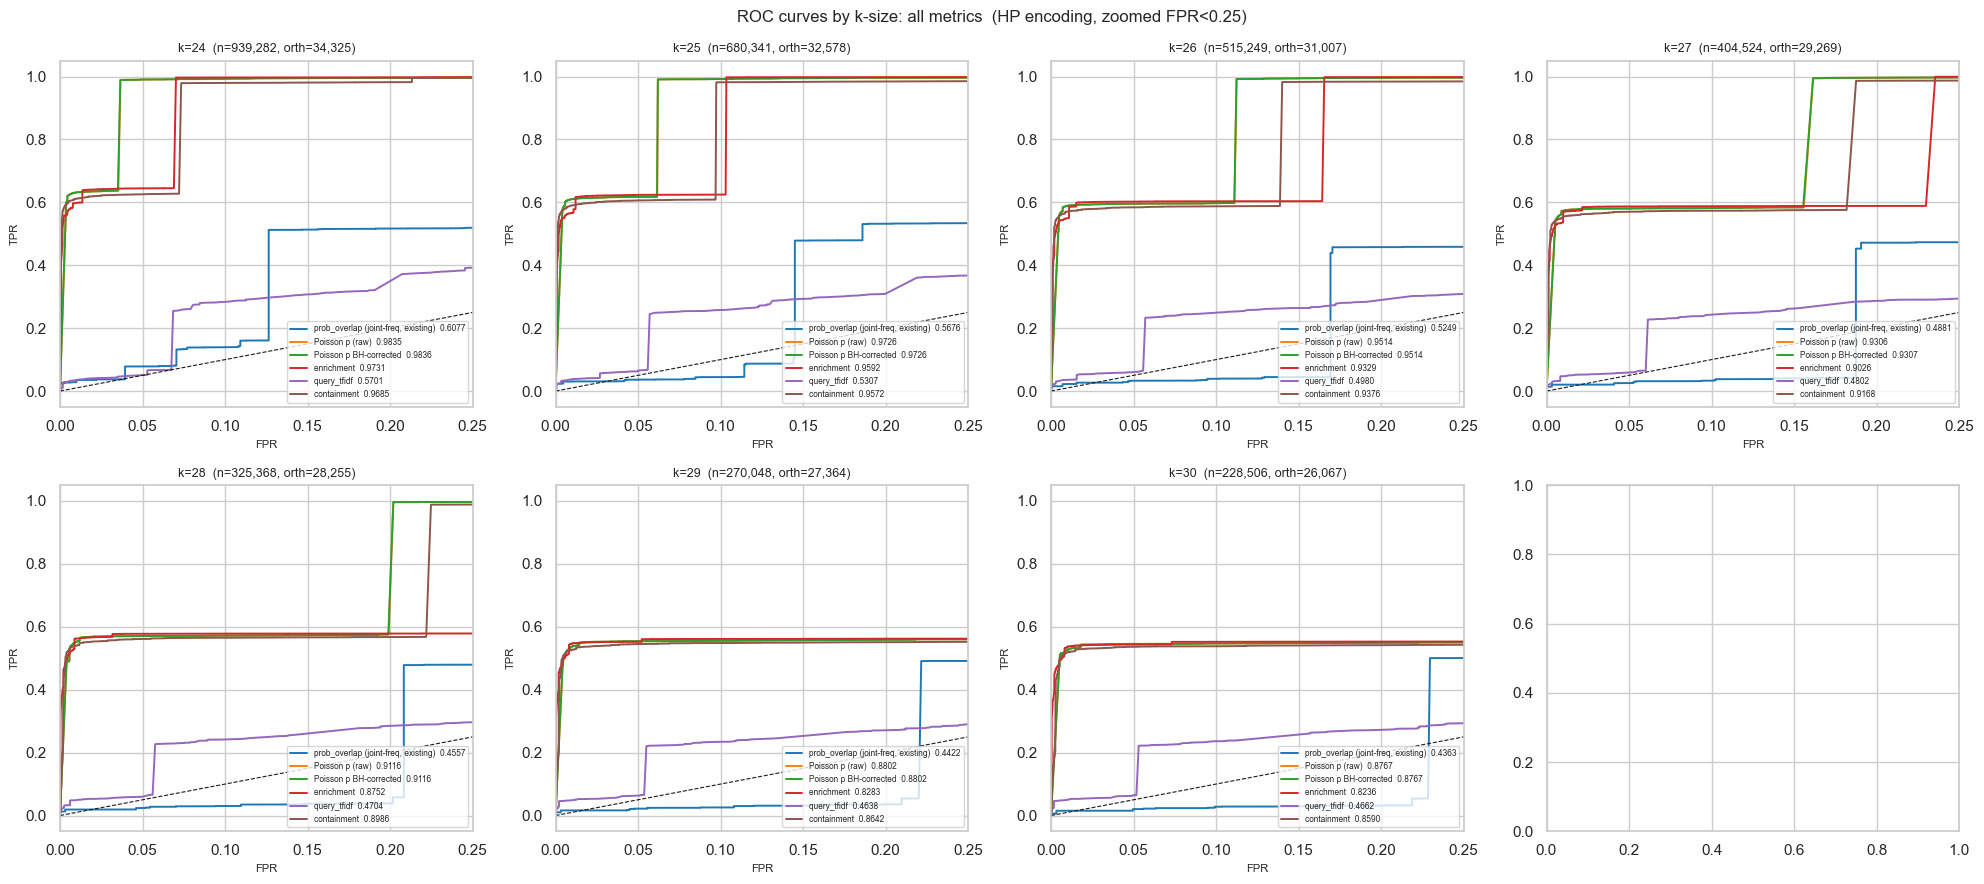

In [24]:
# ── Per-ksize ROC plots (1 subplot per ksize, one curve per metric) ───────────
ncols = 4
nrows = int(np.ceil(len(KSIZES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes_flat = axes.flat

for ax, ks in zip(axes_flat, KSIZES):
    df_k = data_by_ksize[ks]
    y    = df_k['is_ortholog'].astype(int).values
    for (col, hb, label), color in zip(ROC_METRICS, ROC_PAL):
        if col not in df_k.columns:
            continue
        fpr, tpr, auc_val = roc_curves[(ks, label)]
        ax.plot(fpr, tpr, color=color, lw=1.4, label=f'{label}  {auc_val:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(f'k={ks}  (n={len(df_k):,}, orth={df_k["is_ortholog"].sum():,})', fontsize=9)
    ax.set_xlabel('FPR', fontsize=8)
    ax.set_ylabel('TPR', fontsize=8)
    ax.set_xlim(0, 0.25)
    ax.legend(fontsize=6, loc='lower right')

# Hide unused axes
for ax in list(axes_flat)[len(KSIZES):]:
    ax.set_visible(False)

fig.suptitle('ROC curves by k-size: all metrics  (HP encoding, zoomed FPR<0.25)', fontsize=12)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_roc_all_ksizes.png', dpi=120)
plt.show()

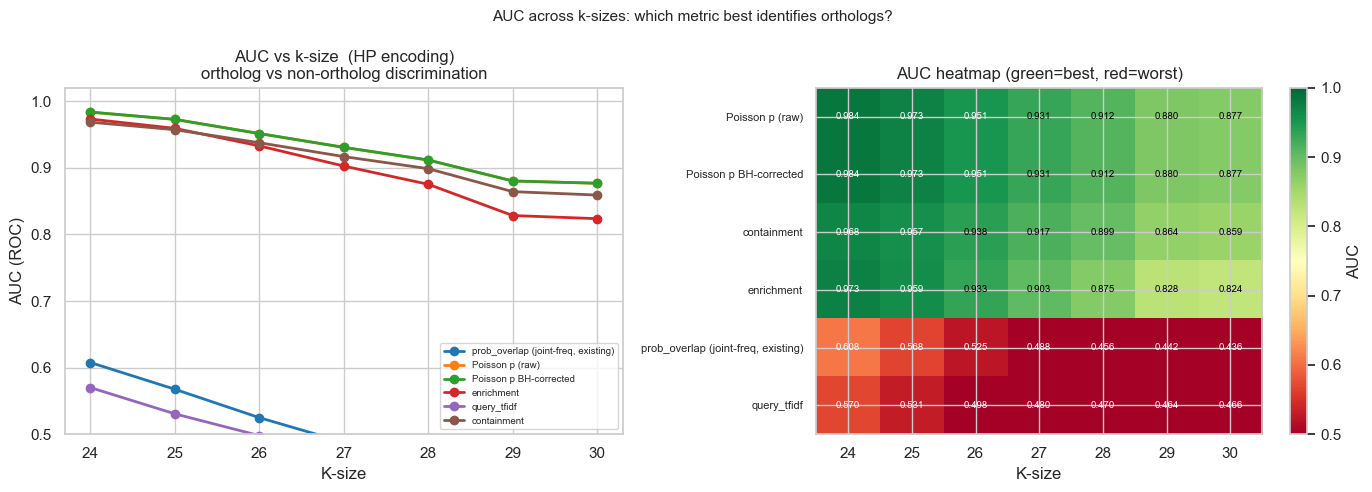


AUC table:
ksize                                    24      25      26      27      28      29      30
metric                                                                                     
Poisson p (raw)                      0.9835  0.9726  0.9514  0.9306  0.9116  0.8802  0.8767
Poisson p BH-corrected               0.9836  0.9726  0.9514  0.9307  0.9116  0.8802  0.8767
containment                          0.9685  0.9572  0.9376  0.9168  0.8986  0.8642  0.8590
enrichment                           0.9731  0.9592  0.9329  0.9026  0.8752  0.8283  0.8236
prob_overlap (joint-freq, existing)  0.6077  0.5676  0.5249  0.4881  0.4557  0.4422  0.4363
query_tfidf                          0.5701  0.5307  0.4980  0.4802  0.4704  0.4638  0.4662


In [25]:
# ── AUC vs ksize summary line plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: AUC vs ksize, one line per metric
ax = axes[0]
for (_, _, label), color in zip(ROC_METRICS, ROC_PAL):
    sub = auc_df[auc_df['metric'] == label].sort_values('ksize')
    ax.plot(sub['ksize'], sub['AUC'], marker='o', color=color, lw=2, label=label)

ax.set_xlabel('K-size')
ax.set_ylabel('AUC (ROC)')
ax.set_title('AUC vs k-size  (HP encoding)\northolog vs non-ortholog discrimination')
ax.legend(fontsize=7, loc='lower right')
ax.set_xticks(KSIZES)
ax.set_ylim(0.5, 1.02)
ax.axhline(0.5, color='k', ls='--', lw=0.8, alpha=0.5)

# Right: ranked bar chart of metrics at each ksize (heatmap style)
pivot = auc_df.pivot(index='metric', columns='ksize', values='AUC')
im = axes[1].imshow(pivot.values, aspect='auto', cmap='RdYlGn',
                     vmin=0.5, vmax=1.0)
axes[1].set_xticks(range(len(KSIZES)))
axes[1].set_xticklabels([str(k) for k in KSIZES])
axes[1].set_yticks(range(len(pivot.index)))
axes[1].set_yticklabels(pivot.index, fontsize=8)
axes[1].set_xlabel('K-size')
axes[1].set_title('AUC heatmap (green=best, red=worst)')
plt.colorbar(im, ax=axes[1], label='AUC')

# Annotate cells
for i in range(len(pivot.index)):
    for j in range(len(KSIZES)):
        val = pivot.values[i, j]
        axes[1].text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7,
                     color='white' if val < 0.7 or val > 0.95 else 'black')

fig.suptitle('AUC across k-sizes: which metric best identifies orthologs?', fontsize=11)
fig.tight_layout()
plt.savefig(f'{DATA_DIR}/analysis_auc_vs_ksize.png', dpi=150)
plt.show()

print("\nAUC table:")
print(pivot.round(4).to_string())